Step 1: Preprocessing & Data Cleaning


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.stats as stats

# 1. Load the dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

# 2. Check for missing values and baseline cleaning
print("--- Missing Values Per Column ---")
print(df.isnull().sum())

# Ensure sorting by time context for pipeline stability
df = df.sort_values(by=['Year', 'Month']).reset_index(drop=True)

--- Missing Values Per Column ---
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


Step 2: Exploratory Data Analysis


Pearson Correlation (Battery vs Range): 0.9943 (p-value: 0.0)


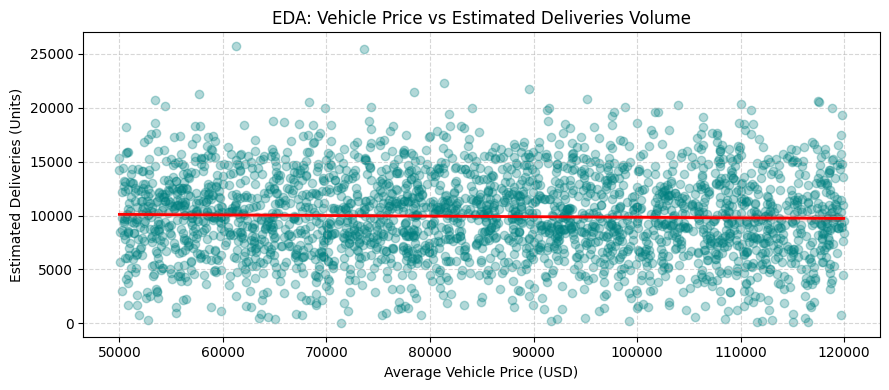

In [5]:
# 1. Bivariate Pearson Correlation
r_val, p_val = stats.pearsonr(df['Battery_Capacity_kWh'], df['Range_km'])
print(f"\nPearson Correlation (Battery vs Range): {r_val:.4f} (p-value: {p_val})")

# 2. Plot Distribution: Price vs Estimated Deliveries
plt.figure(figsize=(9, 4))
sns.regplot(data=df, x='Avg_Price_USD', y='Estimated_Deliveries',
            scatter_kws={'alpha': 0.3, 'color': 'teal'}, line_kws={'color': 'red', 'lw': 2})
plt.title('EDA: Vehicle Price vs Estimated Deliveries Volume')
plt.xlabel('Average Vehicle Price (USD)')
plt.ylabel('Estimated Deliveries (Units)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Step 3: Feature engineering

In [6]:
# 1. Create target deficit feature
df['Delivery_Deficit'] = df['Production_Units'] - df['Estimated_Deliveries']

# 2. Define Features (predicting Estimated_Deliveries volume using price, specifications, region)
X = df[['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km']]
y = df['Estimated_Deliveries']

# 3. Train-Test Split (Splitting into Training and Validation sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Define transformers for categorical and numerical variables
numeric_features = ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km']
categorical_features = ['Region', 'Model']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
print("\nFeature engineering and data preprocessor pipeline constructed successfully.")


Feature engineering and data preprocessor pipeline constructed successfully.


Step 4 & 5: Regression Modeling & Hyperparameter Tuning

In [7]:
# 1. Create an integrated Estimator Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# 2. Define Hyperparameter tuning grids (tuning estimators and depth parameters)
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [10, 15]
}

# 3. Execute Grid Search Cross Validation
grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 4. Extract best tuned model and evaluate metrics
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Regression Model Performance (Tuned Random Forest) ---")
print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")


--- Regression Model Performance (Tuned Random Forest) ---
Optimal Hyperparameters: {'regressor__max_depth': 10, 'regressor__n_estimators': 100}
Mean Absolute Error (MAE): 358.67
Mean Squared Error (MSE): 219518.32
Root Mean Squared Error (RMSE): 468.53
R-squared Score (R²): 0.9862


Step 6: Time Series Forcasting

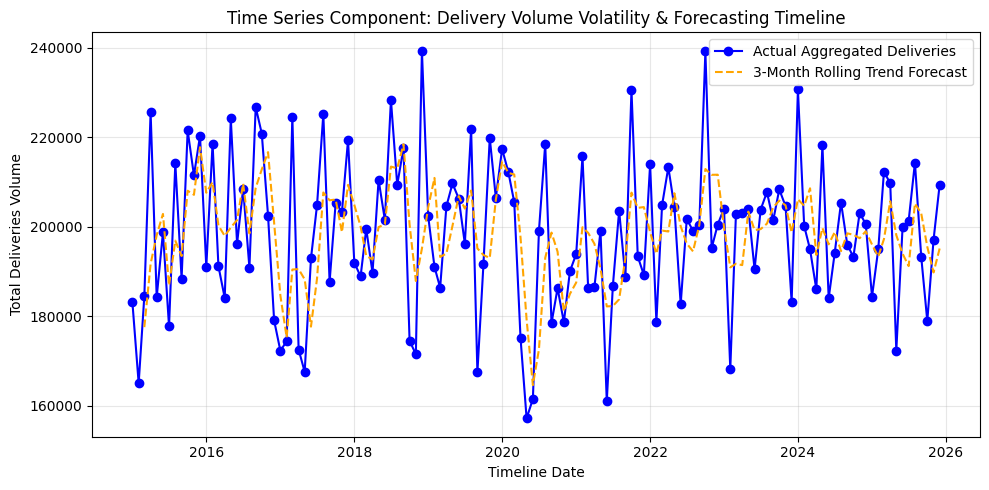

In [8]:
# 1. Convert context columns to a unified datetime continuum index
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
time_series_data = df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()

# 2. Feature-based Time Series Forecasting using rolling windows (3-Month Moving Average)
forecast_df = pd.DataFrame(time_series_data)
forecast_df['3_Month_Moving_Avg_Forecast'] = forecast_df['Estimated_Deliveries'].rolling(window=3).mean()

# 3. Visualize the sales forecasting pipeline output
plt.figure(figsize=(10, 5))
plt.plot(forecast_df.index, forecast_df['Estimated_Deliveries'], label='Actual Aggregated Deliveries', color='blue', marker='o')
plt.plot(forecast_df.index, forecast_df['3_Month_Moving_Avg_Forecast'], label='3-Month Rolling Trend Forecast', color='orange', linestyle='--')
plt.title('Time Series Component: Delivery Volume Volatility & Forecasting Timeline')
plt.xlabel('Timeline Date')
plt.ylabel('Total Deliveries Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()